In [2]:
import numpy as np
import orbitengine.engine as oe
import astropy.units as u
from poliastro.bodies import Earth
from scipy.optimize import minimize
from orbitengine.body import Body
from orbitengine.transfer import TransferSolver, ThrustManeuver
import time
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
from poliastro import iod
import pickle
import math
import os



C:\Users\jcl5m\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ode.py:1179: UserWarning: dopri5: step size becomes too small
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,
C:\Users\jcl5m\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ode.py:1179: UserWarning: dopri5: step size becomes too small
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,


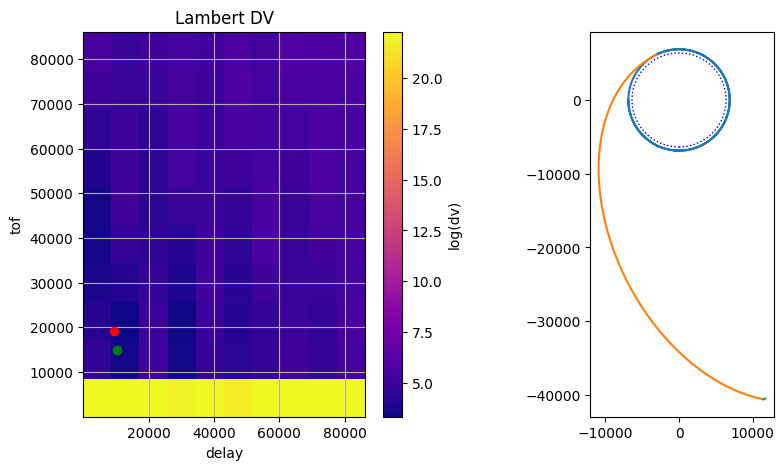

(14.966507273129356, <Quantity 10358.25131335 s>, <Quantity 14944.14839172 s>, <orbitengine.body.Body.State object at 0x0000020D85B30290>)
saved to transfer_1711298783298.pkl
Transfer: dv1: 2.41 dv2: 1.67 t_delay: 10358.251313353485 s t_flight: 14944.148391718429 s


In [3]:
# rocket on ground
r0 = np.array([oe.EARTH_RADIUS_KM.value, 0, 0])*u.km
ground_velocity = oe.EARTH_RADIUS_KM*2*np.pi/(24*3600*u.s)
v0 = np.array([0, ground_velocity.value, 0])*u.km/u.s
#m0 = 100000*u.kg # rocket + fuel
m0 = 10000*u.kg # rocket + fuel
dry_mass =  500*u.kg #rocket only
T0 = oe.TEMP_EARTH
isp = oe.SPECIFIC_IMPULSE_TYPE.Liquid
state_launch = Body.State( r0, v0, m0, T0, parent_axis_angle=oe.EARTH_AXIS_ANGLE)

# compute a target in circular orbit
state_leo = Body.State(np.array([-oe.ALTITUDE_LEO.value, 0, 0])*u.km,
                       np.array([0, -5, 0])*u.km/u.s,   # guess
                        m0,
                        T0).circularized(oe.EARTH_K)
state_geo = Body.State(np.array([-oe.ALTITUDE_GEO.value, 0, 0])*u.km,
                       np.array([0, -5, 0])*u.km/u.s,   # guess
                        m0,
                        T0).circularized(oe.EARTH_K)

load = False
import glob
transfer_filename = 'transfer_*.pkl'
if glob.glob(transfer_filename) and load:
    with open(glob.glob(transfer_filename)[0], 'rb') as f:
        solver = pickle.load(f)
        print(f"loaded from {glob.glob(transfer_filename)[0]}")
else:
#    solver = TransferSolver(state_launch, state_geo, oe.EARTH_K, time_weight=0.0001)
#    solver = TransferSolver(state_launch, state_leo, oe.EARTH_K, time_weight=0.0001)
    solver = TransferSolver(state_leo, state_geo, oe.EARTH_K, time_weight=0.0001)
    print(solver.lambert_search(resolution=10, plot=True))
    transfer_filename = f"transfer_{solver.uuid}.pkl"
    with open(transfer_filename, 'wb') as f:
        pickle.dump(solver, f)
        print(f"saved to {transfer_filename}")

print(f"Transfer: dv1: {solver.dv1:.02f} dv2: {solver.dv2:.02f} t_delay: {solver.t_delay} t_flight: {solver.t_flight}")


saved to transfer_m1_1711298974930.pkl
saved to transfer_m2_1711298974930.pkl
Timestamp: 25449.67066497564 s
Position: [ 11855.94030091 -40462.82454041      0.        ] km
Velocity: [2.95061454 0.86455925 0.        ] km / s
Mass: 6856.1672343515465 kg
Tempurature: 607.5332765648454 K
 7.872836397266512e-13
dV:2.41 1.67  total: 4.07
Initial Mass: 10000.0 kg Final Mass: 6856.1672343515465 kg
Reaction Mass Remaining: 6356.1672343515465 kg
Delay, Flight: 10358.251313353485 s 14944.148391718429 s
m1: 230.84020600218977 s 192.13097048811233 s 2.5856866772262675e-13
m2: 167.11231666111422 s 147.2709599037313 s 5.287149720040244e-13


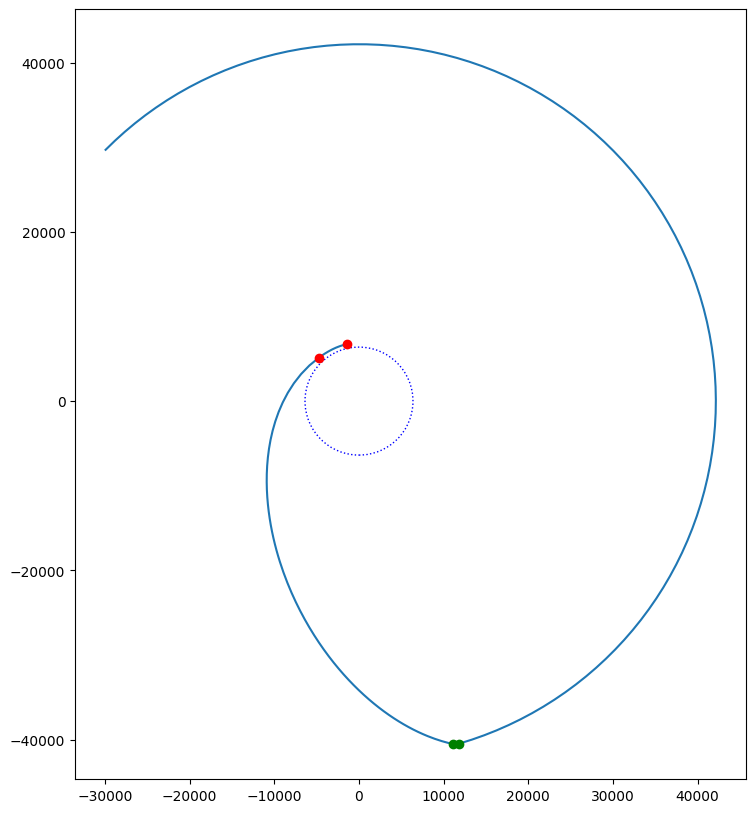

In [7]:
# compute thrust limited maneuvers
flow_rate = 0.005*oe.FALCON9_REACTION_MASS_FLOW_RATE

res = solver.compute_thrust_maneuvers(flow_rate, isp, dry_mass, verbose=False)
if res is not None:
    state, err = res
    print(state, err)
    print(f"m1_dV:{solver.dv1:.02f} m2_dV:{solver.dv2:.02f}  total_dV: {solver.dv1+solver.dv2:.02f}")
    print(f"Initial Mass: {m0:.03f} Final Mass: {state.mass:.03f}")
    print(f"Reaction Mass Remaining: {state.mass - dry_mass}")
    print(f"Delay, Flight: {solver.t_delay:.03f}, {solver.t_flight:.03f}")
    print(f"m1_init_burn: {solver.maneuver1.t_init_burn:.03f}, m1_correction_burn: {solver.maneuver1.t_correction_burn:.03f}, alignment_err: {solver.maneuver1.alignment_err}")
    print(f"m2_init_burn: {solver.maneuver2.t_init_burn:.03f}, m2_correction_burn: {solver.maneuver2.t_correction_burn:.03f}, alignment_err: {solver.maneuver2.alignment_err}")
    solver.plot_thrust_transfer_trajectory(show_maneuvers=False, t_postfix=50000*u.s)


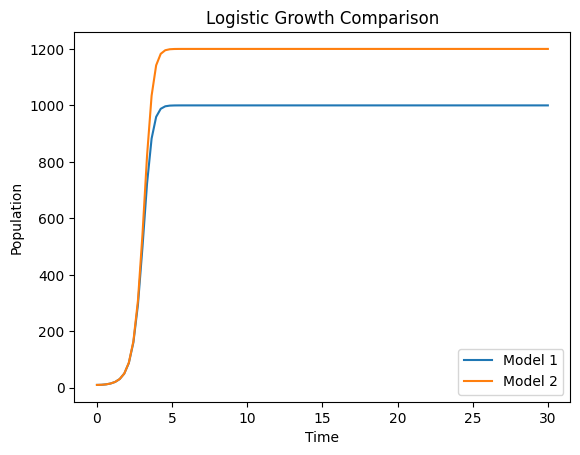

In [5]:
from scipy.integrate import ode
import numpy as np
import matplotlib.pyplot as plt

def logistic_model(t,y, K, r):
    dydt = t * y * (1 - y/K)
    return dydt

# Parameters for model 1
K1 = 1000
r1 = 0.5

# Parameters for model 2
K2 = 1200
r2 = 0.4

# Initial condition (same for both models)
y0 = 10

# Time points
t = np.linspace(0, 30, 100)

# Create separate LSODA integrators
solver1 = ode(logistic_model).set_integrator('dopri5')  # can use dopri5 in re-entrant mode
solver2 = ode(logistic_model).set_integrator('dopri5')

# Set initial conditions
solver1.set_initial_value(y0, t[0])
solver2.set_initial_value(y0, t[0])
solver1.set_f_params(K1, r1)
solver2.set_f_params(K2, r2)
# Solve the ODEs
solution1 = np.zeros((len(t), 1))
solution2 = np.zeros((len(t), 1))
solution1[0] = y0
solution2[0] = y0

for i in range(1, len(t)):
    solution1[i] = solver1.integrate(t[i])
    solution2[i] = solver2.integrate(t[i])

# Plot the results
plt.plot(t, solution1, label='Model 1')
plt.plot(t, solution2, label='Model 2')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Logistic Growth Comparison')
plt.legend()
plt.show()
